Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Thermalized state good; continuing to cavitation.


Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/cavitation_initial.gsd


Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_final.gsd
Evolution status: loaded_evolution
Source status: loaded_source


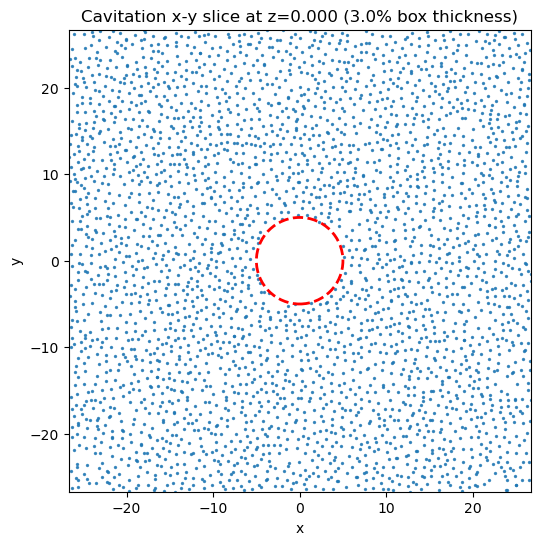

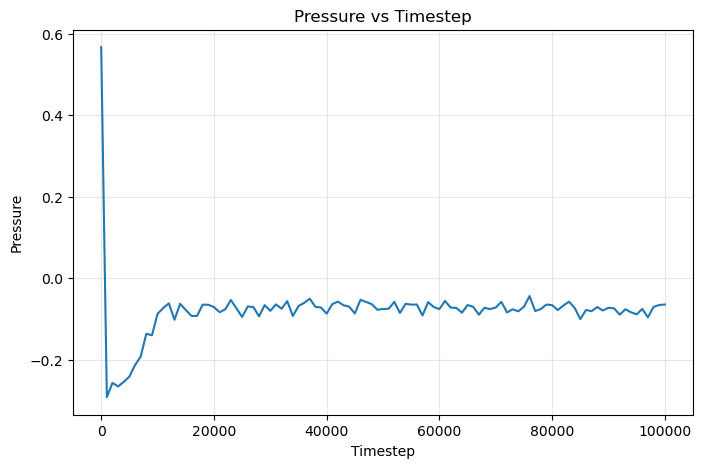

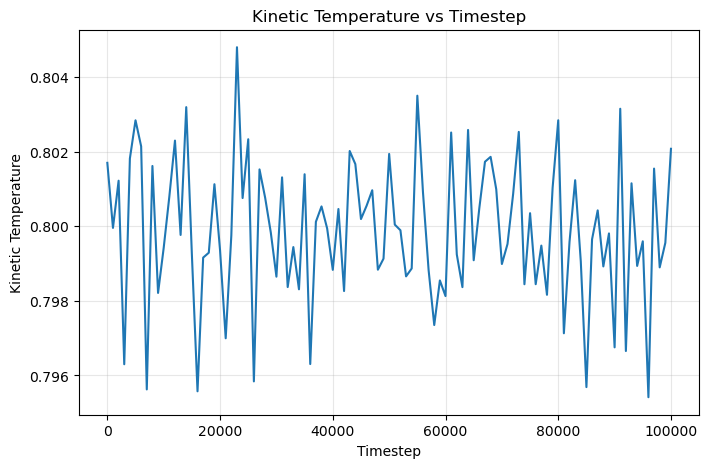

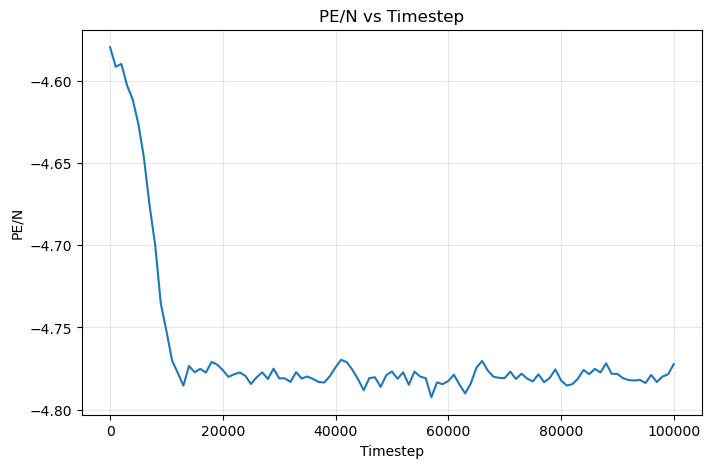

In [4]:
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius=5,
    evolve_nsteps=100_000,

    create_source_if_missing=True,
    overwrite_source=False,
    overwrite=False,
)

print("Evolution status:", evolution["status"])
print("Source status:", evolution["initial_result"]["source_result"]["status"])

vh.plot_cavitation_xy_slice(
    evolution["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [5]:
from md_Helpers import classification as ps

log_path = evolution["paths"]["log_path"]

voxel_data, metadata_path = ps.read_phase_method_attrs(
    log_path,
    "voxel",
)

print("Metadata:", metadata_path)
print("Phase separated:", voxel_data["phase_separated"])
print("Low-density fraction:", voxel_data["low_density_fraction"])
print(voxel_data)

Metadata: metadata/classification/phase_separation/voxel
Phase separated: True
Low-density fraction: 0.03761574074074074
{'density_threshold': 0.2, 'low_density_fraction': 0.03761574074074074, 'max_voxel_density': 0.8747199420438889, 'mean_voxel_density': 0.7076069901532891, 'method': 'voxel_low_density_fraction', 'min_voxel_density': 0.0, 'n_fcc_cells': 30, 'n_voxels': 1728, 'nbins': 12, 'nbins_source': 'n_fcc_cells_rule', 'phase_separated': True, 'std_voxel_density': 0.15055247543527878, 'updated_from_saved_gsd': True, 'voxel_fraction_threshold': 0.01, 'voxel_volume': 88.02817484654595}


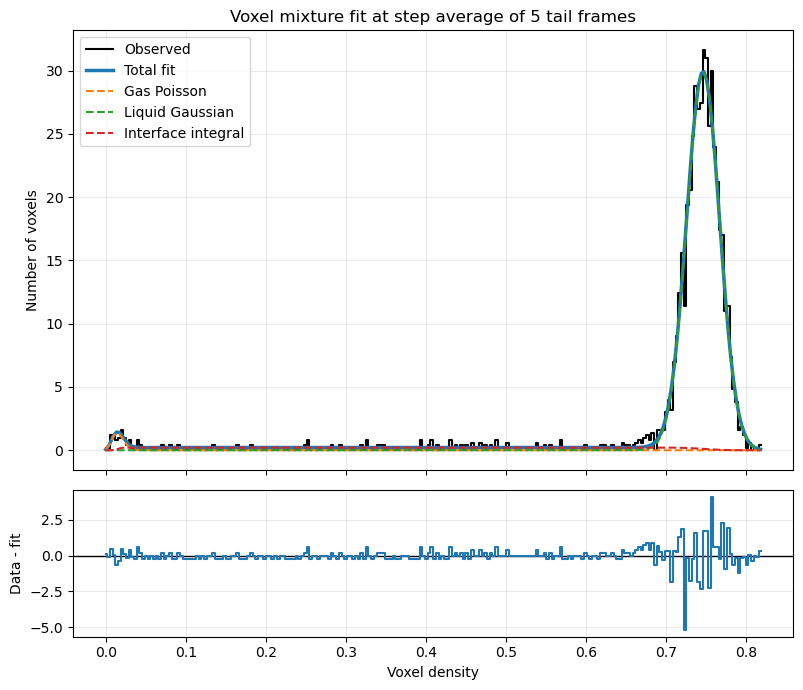

In [6]:
check = vh.fit_and_animate_final_bubble(
    evolution,
    nbins=8,
    nframes=5,
    skip=5,
    tail_fraction=0.2,
)

In [14]:
check['fit']

{'success': True,
 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
 'count_axis': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 'density_axis': array([0.        , 0.09087999, 0.18175999, 0.27263998, 0.36351998,
        0.45439997, 0.54527996, 0.63615996, 0.72703995, 0.81791995,
        0.90879994, 0.99967993, 1.09055993, 1.18143992]),
 'observed_counts': array([ 20. ,  10.4,  10.6,  10.8,  13.2,  27.6,  61.6, 103.2, 110.2,
         82.8,  42.8,  14.6,   3.8,   0.4]),
 'model_counts': array([ 19.99487587,  10.46005807,   9.81758877,  10.4829982 ,
         14.46336658,  28.93347848,  60.86754032,  99.18338222,
        112.04905019,  84.98149412,  42.8294526 ,  14.28595415,
          3.14701126,   0.45714603]),
 'gas_counts': array([1.41572723e+01, 1.00981176e+00, 3.60139923e-02, 8.56270240e-04,
        1.52690387e-05, 2.17822396e-07, 2.58947736e-09, 2.63860825e-11,
        2.35258740e-13, 1.86450733e-15, 1.32991821e-17, 8.62368901e-20,
        5.125

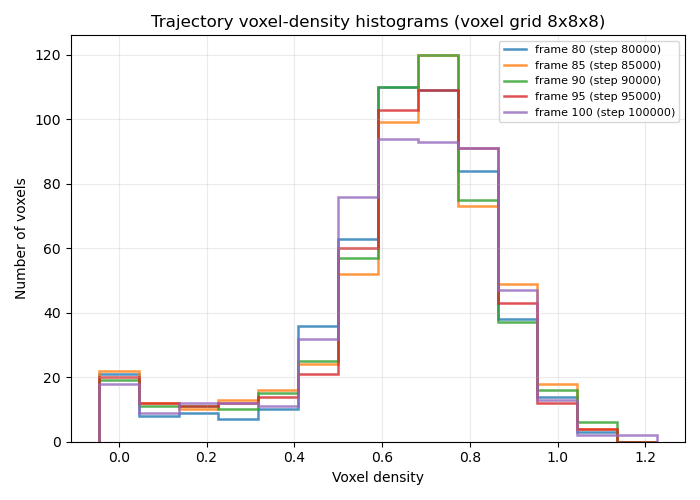

In [15]:
import ipympl

vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=check['fit']['voxel_nbins'],
    frame_indices=check['fit']['frame_indices'],
);

In [21]:
check.keys()

dict_keys(['fit', 'animation', 'fit_frame_indices', 'video_frame_indices', 'frame_indices', 'bubble_radius', 'bubble_volume', 'bubble_volume_fraction'])

In [22]:
check['bubble_radius']

12.47118489395059